In [1]:
import hea
from hea.models import lm, gmm
from hea import data

In [2]:
gpa = data("gpa", package="m-clark")
gpa.head()

student,occas,gpa,job,sex,highgpa,admitted,year,semester,occasion
i64,str,f64,str,str,f64,str,i64,i64,i64
1,"""year 1 semester 1""",2.3,"""2 hours""","""female""",2.8,"""yes""",1,1,0
1,"""year 1 semester 2""",2.1,"""2 hours""","""female""",2.8,"""yes""",1,2,1
1,"""year 2 semester 1""",3.0,"""2 hours""","""female""",2.8,"""yes""",2,1,2
1,"""year 2 semester 2""",3.0,"""2 hours""","""female""",2.8,"""yes""",2,2,3
1,"""year 3 semester 1""",3.0,"""2 hours""","""female""",2.8,"""yes""",3,1,4


In [3]:
gpa_lm = lm("gpa ~ occasion", data=gpa)
gpa_lm.summary()

Formula: gpa ~ occasion

Residuals:
     Min       1Q   Median      3Q     Max
-0.90553 -0.22447 -0.01184 0.26921 1.19447

Coefficients:
             Estimate  Std. Error  CI[2.5%]  CI[97.5]%  t value  Pr(>|t|)
(Intercept)  2.599214    0.017846   2.56420    2.63423   145.65    <2e-16  ***
occasion     0.106314    0.005894   0.09475    0.11788    18.04    <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

n = 1200, p = 2, Residual SE = 0.349 on 1198 DF
R-Squared = 0.2136, adjusted R-Squared = 0.2129
F-statistics = 325.3394 on 1 and 1198 DF, p-value: 1.573827e-64

Log Likelihood = -437.4883, AIC = 880.9766, BIC = 896.2468

In [4]:
gpa_mixed = gmm("gpa ~ occasion + (1 | student)", data=gpa)
gpa_mixed.summary()

Linear mixed model fit by REML ['lmerMod']
Formula: gpa ~ occasion + (1 | student)

REML criterion at convergence: 408.8929

Scaled residuals:
    Min      1Q  Median     3Q    Max
-3.6169 -0.6373 -0.0004 0.6361 2.8310

Random effects:
 Groups   Name        Variance Std.Dev.
 student  (Intercept)  0.06372   0.2524
 Residual              0.05809   0.2410
Number of obs: 1200, groups:  student, 200

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  2.599214    0.021696   119.80
occasion     0.106314    0.004074    26.10

Correlation of Fixed Effects:
         (Intr)
occasion -0.469


In [5]:
gpa_mixed.confint()

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",0.225174,0.28246
""".sigma""",0.230711,0.251851
"""(Intercept)""",2.556651,2.641777
"""occasion""",0.098326,0.114303


In [6]:
gpa_mixed.ranef()["student"].head(5)

student,(Intercept)
i64,f64
1,-0.070895
2,-0.215578
3,0.088257
4,-0.186642
5,0.030384


In [7]:
pred = hea.tidy.DataFrame(
    {
        "student": gpa["student"],
        "occasion": gpa["occasion"],
        "lm": gpa_lm.predict(),
        "gmm w/o re": gpa_mixed.predict(re_form=False),
        "gmm w/ re": gpa_mixed.predict(),
    }
)
pred

student,occasion,lm,gmm w/o re,gmm w/ re
i64,i64,f64,f64,f64
1,0,2.599214,2.599214,2.528319
1,1,2.705529,2.705529,2.634634
1,2,2.811843,2.811843,2.740948
1,3,2.918157,2.918157,2.847262
1,4,3.024471,3.024471,2.953577
…,…,…,…,…
200,1,2.705529,2.705529,3.054216
200,2,2.811843,2.811843,3.16053
200,3,2.918157,2.918157,3.266844


In [8]:
gpa_mixed_2 = gmm("gpa ~ occasion + (1 + occasion | student)", data=gpa)
gpa_mixed_2.summary()

Linear mixed model fit by REML ['lmerMod']
Formula: gpa ~ occasion + (1 + occasion | student)

REML criterion at convergence: 260.9566

Scaled residuals:
    Min      1Q  Median     3Q    Max
-3.2695 -0.5377 -0.0128 0.5326 3.1939

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 student  (Intercept) 0.045194  0.21259
          occasion    0.004504  0.06711 -0.10
 Residual             0.042388  0.20588
Number of obs: 1200, groups:  student, 200

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)  2.599214    0.018357   141.59
occasion     0.106314    0.005885    18.07

Correlation of Fixed Effects:
         (Intr)
occasion -0.345


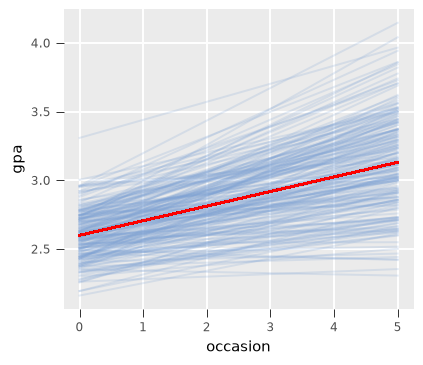

In [9]:
(
    gpa.mutate(
        lm=gpa_lm.predict(newdata=gpa)["fit"],
        mixed=gpa_mixed_2.predict(newdata=gpa)["fit"],
    )
    .ggplot(x="occasion", group="student")
    .geom_line(y="mixed", color="#7ba0d4", alpha=0.2, size=0.5)
    .geom_line(y="lm", color="red")
    .labs(y="gpa")
)

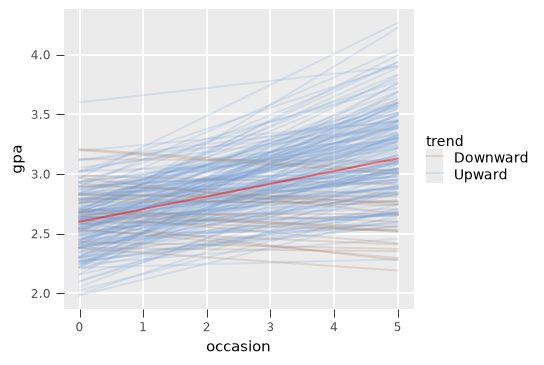

In [10]:
def fit_per_student(g):
    m = lm("gpa ~ occasion", data=g)
    return g.mutate(
        stufit=m.yhat["fit"],
        trend="Downward" if float(m._bhat_arr[1]) < 0 else "Upward",
    )


per_student = hea.tidy.concat(
    [fit_per_student(g) for g in gpa.partition_by("student", maintain_order=True)]
).mutate(
    pop_fit=gpa_lm.predict(newdata=gpa)["fit"],  # 1 prediction per row
)

(
    per_student.ggplot(x="occasion")
    .geom_line(y="stufit", color="trend", group="student", alpha=0.2, size=0.5)
    .geom_line(
        y="pop_fit",
        color="red",
        alpha=0.5,
        size=0.5,
        data=per_student.distinct("occasion", keep_all=True).arrange("occasion"),
    )
    .scale_color_manual(values={"Downward": "#a37551", "Upward": "#7ba0d4"})
    .labs(y="gpa")
)

In [11]:
from hea import session_info

session_info()

Python version 3.13.11 (CPython)
Platform: arm64-darwin25.4.0
Running under: macOS 26.4.1

BLAS:   accelerate
LAPACK: accelerate

locale: C.UTF-8

time zone: CEST

hea version 0.1.9

attached packages:
[1] IPython_9.14.1    hea_0.1.9         matplotlib_3.11.0 numpy_2.5.0
[5] pandas_3.0.3      polars_1.41.2     pyarrow_24.0.0    pytest_9.1.1
[9] scipy_1.18.0

loaded via a namespace (and not attached):
 [1] Cython_3.2.9             PIL_12.2.0               appnope_0.1.4
 [4] argparse_1.1             asttokens_3.0.1          charset_normalizer_3.4.7
 [7] comm_0.2.3               csv_1.0                  ctypes_1.1.0
[10] cycler_0.12.1            cython_3.2.9             dateutil_2.9.0.post0
[13] debugpy_1.8.21           decimal_1.70             decorator_5.3.1
[16] defusedxml_0.7.1         executing_2.2.1          fontTools_4.63.0
[19] ipaddress_1.0            ipykernel_7.3.0          jedi_0.20.0
[22] json_2.0.9               jupyter_client_8.9.1     jupyter_core_5.9.1
[25] kiwisolver_1.5